# Tech Pulse v3 — Advanced Framework

Loads precomputed signals from GitHub (saved by v2 Section 22) and runs:

1. **S&P 500 benchmark** — compare all strategies against SPY
2. **Asymmetric sentiment** — per-ticker positive/negative weighting
3. **Refined sectors** — split Fintech/Crypto, add Cybersecurity, Semiconductor Supply Chain
4. **Sector quality weighting** — allocate more to high-quality sectors
5. **Cross-company spillover signals** — wire confirmed pairs into strategy
6. **Combined strategy** — sector rotation + weighted position entry + spillover

**Prerequisite:** Run Section 22 of `tech_pulse_v2.ipynb` first.

---
## 0. Install

In [1]:
# !pip install pandas requests python-dotenv matplotlib seaborn scipy

---
## 1. Configuration & Load

In [2]:
import os, io, requests, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from datetime import datetime, timezone
from dotenv import load_dotenv
load_dotenv()

GITHUB_REPO    = 'annhmartin/dataviz-historical-stocks-AnnetteMartin'
GITHUB_TOKEN   = os.environ.get('GITHUB_TOKEN', None)
OUTPUT_PREFIX  = 'tech_pulse_outputs'
STOCKS_PREFIX  = 'stocks'
SENTIMENT_THRESHOLD = 0.05
ZSCORE_THRESHOLD    = 2.0

# Asymmetric sentiment weights (from v2 finding: 19/24 tickers respond more to positive)
POSITIVE_WEIGHT = 1.5
NEGATIVE_WEIGHT = 0.6

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc', 'axes.grid': True,
    'grid.color': '#e8e8e8', 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
})

def load_output(filename, token=None):
    url = f'https://raw.githubusercontent.com/{GITHUB_REPO}/main/{OUTPUT_PREFIX}/{filename}'
    headers = {'Authorization': f'Bearer {token}'} if token else {}
    resp = requests.get(url, headers=headers, timeout=60)
    if resp.status_code == 404:
        raise FileNotFoundError(f'{filename} not found — run Section 22 of v2 first')
    resp.raise_for_status()
    return pd.read_csv(io.StringIO(resp.text.strip()), low_memory=False)

def load_stock(ticker, token=None):
    url = f'https://raw.githubusercontent.com/{GITHUB_REPO}/main/{STOCKS_PREFIX}/prices_{ticker}.csv'
    headers = {'Authorization': f'Bearer {token}'} if token else {}
    resp = requests.get(url, headers=headers, timeout=60)
    if resp.status_code == 404: raise FileNotFoundError(ticker)
    resp.raise_for_status()
    df = pd.read_csv(io.StringIO(resp.text.strip()), low_memory=False)
    df['Date'] = pd.to_datetime(df['Date'])
    df['daily_return'] = df['Close'].pct_change(fill_method=None)
    return df.sort_values('Date').reset_index(drop=True)

print('Loading precomputed outputs ...')
daily_signals   = load_output('daily_signals.csv',   GITHUB_TOKEN)
df_prices       = load_output('df_prices.csv',       GITHUB_TOKEN)
best_per_ticker = load_output('best_per_ticker.csv', GITHUB_TOKEN)
df_corr         = load_output('df_corr.csv',         GITHUB_TOKEN)
df_company_map  = load_output('company_map.csv',     GITHUB_TOKEN)

# Load SPY benchmark
try:
    df_spy = load_stock('SPY', GITHUB_TOKEN)
    df_spy = df_spy.set_index('Date').sort_index()
    SPY_AVAILABLE = True
    print(f'SPY: {len(df_spy):,} rows ({df_spy.index.min().date()} to {df_spy.index.max().date()})')
except FileNotFoundError:
    SPY_AVAILABLE = False
    print('SPY not found — fetch with yfinance and add to stocks/ folder')

# Rebuild COMPANY_MAP
COMPANY_MAP = {
    row['ticker']: {'names': row['names'].split('|'), 'keywords': row['keywords'].split('|')}
    for _, row in df_company_map.iterrows()
}
daily_signals['date'] = pd.to_datetime(daily_signals['date'])
df_prices['Date']     = pd.to_datetime(df_prices['Date'])
all_tickers = daily_signals['ticker'].unique().tolist()
top5 = best_per_ticker.head(5)['ticker'].tolist()

print(f'Loaded: {len(daily_signals):,} signal rows, {len(df_prices):,} price rows')
print(f'Tickers: {len(all_tickers)} | Top 5: {top5}')

Loading precomputed outputs ...
SPY: 4,149 rows (2010-01-04 to 2026-07-02)
Loaded: 121,771 signal rows, 81,953 price rows
Tickers: 29 | Top 5: ['PANW', 'NVO', 'CRWD', 'PLTR', 'PM']


---
## 1b. Load Reddit Sentiment

Loads Reddit posts from `reddit_data/` and scores them with VADER.
Covers r/wallstreetbets, r/stocks, r/investing, r/technology, r/SecurityAnalysis.

Reddit sentiment is merged with HN sentiment using configurable source weights:
- HN: 1.0 (tech-expert audience, high signal for tech stocks)
- Reddit: 0.8 (higher volume, noisier, but broader company coverage)
- GDELT: 0.9 (mainstream news, best for missed moves)
- EDGAR: 1.5 (hard facts, highest signal — added as event markers)

In [4]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


ANALYSIS_START = '2015-01-01'
ANALYSIS_END   = '2026-06-30'

# Source weights — adjust to change how much each source influences the signal
SOURCE_WEIGHTS = {
    'hn'    : 1.0,
    'reddit': 0.8,
    'gdelt' : 0.9,
}

REDDIT_PREFIX = 'reddit_data'
GDELT_PREFIX  = 'gdelt_data'
EDGAR_PREFIX  = 'edgar_data'

analyzer = SentimentIntensityAnalyzer()

def score_text(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    return analyzer.polarity_scores(text)['compound']

print('Loading Reddit data ...')
reddit_frames = []
start_year = int(ANALYSIS_START[:4])
end_year   = int(ANALYSIS_END[:4])

for year in range(start_year, end_year + 1):
    try:
        df_r = load_output(f'../../{REDDIT_PREFIX}/reddit_{year}.csv')
        reddit_frames.append(df_r)
        print(f'  {year}: {len(df_r):,} posts', end='  ')
    except Exception:
        # Try direct GitHub load
        try:
            url = f'https://raw.githubusercontent.com/{GITHUB_REPO}/main/{REDDIT_PREFIX}/reddit_{year}.csv'
            headers = {'Authorization': f'Bearer {GITHUB_TOKEN}'} if GITHUB_TOKEN else {}
            import requests, io
            resp = requests.get(url, headers=headers, timeout=60)
            if resp.status_code == 200:
                df_r = pd.read_csv(io.StringIO(resp.text.strip()), low_memory=False)
                reddit_frames.append(df_r)
                print(f'  {year}: {len(df_r):,} posts', end='  ')
        except Exception as e:
            pass

if reddit_frames:
    df_reddit = pd.concat(reddit_frames, ignore_index=True).drop_duplicates(subset='id').reset_index(drop=True)
    df_reddit['date'] = pd.to_datetime(df_reddit['date'], errors='coerce')
    df_reddit = df_reddit[
        (df_reddit['date'] >= ANALYSIS_START) &
        (df_reddit['date'] <= ANALYSIS_END)
    ].reset_index(drop=True)
    df_reddit['sentiment'] = df_reddit['title'].fillna('').apply(score_text)
    REDDIT_AVAILABLE = True
    print(f'\nReddit loaded: {len(df_reddit):,} posts, {df_reddit["date"].nunique():,} unique days')
else:
    df_reddit = pd.DataFrame()
    REDDIT_AVAILABLE = False
    print('\nNo Reddit data found — run reddit_collector.ipynb first')

Loading Reddit data ...
  2015: 33,153 posts    2016: 39,828 posts    2017: 45,015 posts    2018: 47,354 posts    2019: 46,194 posts    2020: 41,959 posts    2021: 56,068 posts    2022: 39,464 posts    2023: 43,856 posts    2024: 21,202 posts    2025: 21,958 posts    2026: 13,166 posts  
Reddit loaded: 447,756 posts, 3,673 unique days


---
## 1c. Load GDELT Sentiment

Loads GDELT news sentiment from `gdelt_data/` (pre-scored tone values).
GDELT tone ranges from roughly -100 (very negative) to +100 (very positive).
Normalized to the same -1 to +1 scale as VADER before merging.

In [5]:
print('Loading GDELT data ...')
gdelt_frames = []

for ticker in COMPANY_MAP.keys():
    for year in range(start_year, end_year + 1):
        try:
            url = f'https://raw.githubusercontent.com/{GITHUB_REPO}/main/{GDELT_PREFIX}/gdelt_{ticker}_{year}.csv'
            headers = {'Authorization': f'Bearer {GITHUB_TOKEN}'} if GITHUB_TOKEN else {}
            resp = requests.get(url, headers=headers, timeout=30)
            if resp.status_code == 200:
                df_g = pd.read_csv(io.StringIO(resp.text.strip()), low_memory=False)
                if not df_g.empty:
                    gdelt_frames.append(df_g)
        except Exception:
            pass

if gdelt_frames:
    df_gdelt = pd.concat(gdelt_frames, ignore_index=True)
    df_gdelt['date'] = pd.to_datetime(df_gdelt['date'], errors='coerce')
    df_gdelt = df_gdelt[
        (df_gdelt['date'] >= ANALYSIS_START) &
        (df_gdelt['date'] <= ANALYSIS_END)
    ].dropna(subset=['date']).reset_index(drop=True)
    # Normalize GDELT tone from ~(-100,+100) to (-1,+1)
    df_gdelt['sentiment'] = (df_gdelt['tone'] / 10).clip(-1, 1)
    df_gdelt['sentiment_label'] = df_gdelt['sentiment'].apply(
        lambda s: 'positive' if s >= SENTIMENT_THRESHOLD
                  else ('negative' if s <= -SENTIMENT_THRESHOLD else 'neutral')
    )
    GDELT_AVAILABLE = True
    print(f'GDELT loaded: {len(df_gdelt):,} articles across {df_gdelt["ticker"].nunique()} tickers')
    print(f'Date range: {df_gdelt["date"].min().date()} to {df_gdelt["date"].max().date()}')
else:
    df_gdelt = pd.DataFrame()
    GDELT_AVAILABLE = False
    print('No GDELT data found — run gdelt_collector.ipynb first')

Loading GDELT data ...
GDELT loaded: 250,812 articles across 27 tickers
Date range: 2017-01-11 to 2026-06-30


---
## 1d. Load EDGAR Filing Events

Loads SEC filing metadata as event markers.
EDGAR doesn't contribute sentiment scores but flags days with material events
(8-K filings = earnings/announcements) which get a signal boost in the combined model.

**Edgar event boost:** On days with an 8-K filing, the sentiment signal weight
is multiplied by `EDGAR_BOOST` — because buzz on the same day as a material
event is more likely to be predictive.

In [6]:
EDGAR_BOOST = 1.5   # multiply signal weight on 8-K filing days

print('Loading EDGAR filing events ...')
edgar_frames = []

for ticker in COMPANY_MAP.keys():
    try:
        url = f'https://raw.githubusercontent.com/{GITHUB_REPO}/main/{EDGAR_PREFIX}/edgar_{ticker}.csv'
        headers = {'Authorization': f'Bearer {GITHUB_TOKEN}'} if GITHUB_TOKEN else {}
        resp = requests.get(url, headers=headers, timeout=30)
        if resp.status_code == 200:
            df_e = pd.read_csv(io.StringIO(resp.text.strip()), low_memory=False)
            df_e['ticker'] = ticker
            edgar_frames.append(df_e)
    except Exception:
        pass

if edgar_frames:
    df_edgar = pd.concat(edgar_frames, ignore_index=True)
    df_edgar['date'] = pd.to_datetime(df_edgar['date'], errors='coerce')
    df_edgar = df_edgar.dropna(subset=['date']).reset_index(drop=True)
    # Build set of (ticker, date) pairs where an 8-K was filed
    eight_k_dates = set(
        zip(
            df_edgar[df_edgar['form']=='8-K']['ticker'],
            df_edgar[df_edgar['form']=='8-K']['date'].dt.date.astype(str)
        )
    )
    EDGAR_AVAILABLE = True
    print(f'EDGAR loaded: {len(df_edgar):,} filings across {df_edgar["ticker"].nunique()} tickers')
    print(f'8-K filing days: {len(eight_k_dates):,} ticker-date pairs')
    print(f'Edgar boost: x{EDGAR_BOOST} on 8-K filing days')
else:
    df_edgar = pd.DataFrame()
    eight_k_dates = set()
    EDGAR_AVAILABLE = False
    print('No EDGAR data found — run edgar_collector.ipynb first')

Loading EDGAR filing events ...
EDGAR loaded: 6,298 filings across 24 tickers
8-K filing days: 4,421 ticker-date pairs
Edgar boost: x1.5 on 8-K filing days


---
## 1e. Merge All Sources into Combined Daily Signals

Combines HN, Reddit, and GDELT into one daily sentiment signal per ticker.
Each source is weighted by `SOURCE_WEIGHTS` before averaging.
Days with EDGAR 8-K filings get an additional `EDGAR_BOOST` multiplier.

In [7]:
print('Merging sentiment sources ...')

# Build company-matched Reddit sentiment by day
def match_reddit_to_tickers(df_reddit, company_map):
    if df_reddit.empty:
        return pd.DataFrame()
    rows = []
    for _, row in df_reddit.iterrows():
        text = str(row.get('title', '') or '')
        text_lower = text.lower()
        words = set(text_lower.split())
        for ticker, info in company_map.items():
            if ticker.lower() in words:
                rows.append({'ticker': ticker, 'date': row['date'],
                             'sentiment': row['sentiment'], 'source': 'reddit',
                             'points': row.get('score', 1)})
                continue
            if any(name in text_lower for name in info['names']):
                rows.append({'ticker': ticker, 'date': row['date'],
                             'sentiment': row['sentiment'], 'source': 'reddit',
                             'points': row.get('score', 1)})
                continue
            if any(kw in text_lower for kw in info['keywords']):
                rows.append({'ticker': ticker, 'date': row['date'],
                             'sentiment': row['sentiment'], 'source': 'reddit',
                             'points': row.get('score', 1)})
    return pd.DataFrame(rows)

# Tag HN signals with source
hn_long = daily_signals[['ticker','date','norm_sentiment','story_count']].copy()
hn_long = hn_long.dropna(subset=['norm_sentiment'])
hn_long['source'] = 'hn'
hn_long['weight'] = SOURCE_WEIGHTS['hn']
hn_long = hn_long.rename(columns={'norm_sentiment': 'sentiment'})

all_source_frames = [hn_long[['ticker','date','sentiment','source','weight','story_count']]]

# Add Reddit
if REDDIT_AVAILABLE:
    print('  Matching Reddit posts to companies ...')
    df_reddit_matched = match_reddit_to_tickers(df_reddit, COMPANY_MAP)
    if not df_reddit_matched.empty:
        df_reddit_matched['date']   = pd.to_datetime(df_reddit_matched['date'])
        df_reddit_matched['weight'] = SOURCE_WEIGHTS['reddit']
        df_reddit_matched['story_count'] = 1
        all_source_frames.append(
            df_reddit_matched[['ticker','date','sentiment','source','weight','story_count']]
        )
        print(f'  Reddit: {len(df_reddit_matched):,} ticker-story matches')

# Add GDELT
if GDELT_AVAILABLE:
    gdelt_long = df_gdelt[['ticker','date','sentiment']].copy()
    gdelt_long['source'] = 'gdelt'
    gdelt_long['weight'] = SOURCE_WEIGHTS['gdelt']
    gdelt_long['story_count'] = 1
    all_source_frames.append(
        gdelt_long[['ticker','date','sentiment','source','weight','story_count']]
    )
    print(f'  GDELT: {len(gdelt_long):,} ticker-article matches')

# Combine all sources
df_combined_raw = pd.concat(all_source_frames, ignore_index=True)
df_combined_raw['date'] = pd.to_datetime(df_combined_raw['date'])
df_combined_raw['weighted_sent'] = df_combined_raw['sentiment'] * df_combined_raw['weight']

# Aggregate to daily per ticker
daily_combined = (
    df_combined_raw.groupby(['ticker','date'])
    .agg(
        combined_sentiment = ('weighted_sent', lambda x:
            x.sum() / df_combined_raw.loc[x.index, 'weight'].sum()
            if df_combined_raw.loc[x.index, 'weight'].sum() > 0 else np.nan),
        total_stories      = ('story_count', 'sum'),
        source_count       = ('source', 'nunique'),
    )
    .reset_index()
)

# Apply EDGAR 8-K boost
if EDGAR_AVAILABLE:
    def apply_edgar_boost(row):
        key = (row['ticker'], str(row['date'].date()))
        if key in eight_k_dates and not pd.isna(row['combined_sentiment']):
            return row['combined_sentiment'] * EDGAR_BOOST
        return row['combined_sentiment']
    daily_combined['combined_sentiment'] = daily_combined.apply(apply_edgar_boost, axis=1)
    print(f'  EDGAR 8-K boost applied to {len(eight_k_dates):,} filing days')

# Merge back into daily_signals for use in all downstream sections
daily_signals = daily_signals.merge(
    daily_combined[['ticker','date','combined_sentiment','total_stories','source_count']],
    on=['ticker','date'], how='left'
)
# Use combined_sentiment where available, fall back to norm_sentiment
daily_signals['final_sentiment'] = daily_signals['combined_sentiment'].fillna(
    daily_signals['norm_sentiment']
)

# Recompute rolling signals on final_sentiment
print('  Recomputing rolling signals on combined sentiment ...')
signal_frames_new = []
for ticker in all_tickers:
    t = daily_signals[daily_signals['ticker']==ticker].copy().sort_values('date')
    for w in [1, 3, 5, 7]:
        t[f'comb_roll_{w}d'] = t['final_sentiment'].rolling(w, min_periods=1).mean()
    t['comb_momentum'] = t['comb_roll_3d'] - t['comb_roll_3d'].shift(7)
    signal_frames_new.append(t)
daily_signals = pd.concat(signal_frames_new, ignore_index=True)

sources_active = ['HN']
if REDDIT_AVAILABLE: sources_active.append('Reddit')
if GDELT_AVAILABLE:  sources_active.append('GDELT')
if EDGAR_AVAILABLE:  sources_active.append('EDGAR events')
print(f'\nCombined signal ready: {len(daily_signals):,} ticker-days')
print(f'Active sources: {" + ".join(sources_active)}')
print(f'Coverage improvement: {daily_signals["combined_sentiment"].notna().sum():,} days with signal')
print(f'  vs HN alone:        {daily_signals["norm_sentiment"].notna().sum():,} days with signal')

Merging sentiment sources ...
  Matching Reddit posts to companies ...
  Reddit: 84,667 ticker-story matches
  GDELT: 250,812 ticker-article matches
  EDGAR 8-K boost applied to 4,421 filing days
  Recomputing rolling signals on combined sentiment ...

Combined signal ready: 121,771 ticker-days
Active sources: HN + Reddit + GDELT + EDGAR events
Coverage improvement: 48,704 days with signal
  vs HN alone:        27,335 days with signal


---
## 2. Fetch SPY if Not Already in GitHub

Run this only if SPY showed 'not found' above.

In [8]:
if not SPY_AVAILABLE:
    try:
        import yfinance as yf
        import base64, io

        print('Fetching SPY from Yahoo Finance ...')
        df_spy_raw = yf.download('SPY', start='2010-01-01', progress=False, auto_adjust=True)
        if isinstance(df_spy_raw.columns, pd.MultiIndex):
            df_spy_raw.columns = df_spy_raw.columns.get_level_values(0)
        df_spy_raw = df_spy_raw.reset_index()
        df_spy_raw['ticker'] = 'SPY'

        # Push to GitHub
        buf = io.StringIO()
        df_spy_raw.to_csv(buf, index=False)
        encoded = base64.b64encode(buf.getvalue().encode()).decode()
        url = f'https://api.github.com/repos/{GITHUB_REPO}/contents/{STOCKS_PREFIX}/prices_SPY.csv'
        headers = {
            'Authorization': f'Bearer {GITHUB_TOKEN}',
            'Accept': 'application/vnd.github+json',
            'X-GitHub-Api-Version': '2022-11-28',
        }
        check = requests.get(url, headers=headers, timeout=15)
        sha = check.json().get('sha') if check.status_code == 200 else None
        payload = {'message': f'Add SPY prices ({len(df_spy_raw):,} rows)', 'content': encoded}
        if sha: payload['sha'] = sha
        resp = requests.put(url, headers=headers, json=payload, timeout=60)
        print(f'SPY pushed: {resp.status_code} | {len(df_spy_raw):,} rows')

        df_spy = df_spy_raw.set_index('Date').sort_index()
        df_spy['daily_return'] = df_spy['Close'].pct_change(fill_method=None)
        SPY_AVAILABLE = True
    except ImportError:
        print('yfinance not installed: !pip install yfinance')
else:
    print('SPY already loaded')

SPY already loaded


---
## 3. Refined Sector Map

Based on v2 findings:
- **Fintech/Crypto split** — COIN + TSLA behave as macro risk instruments; PYPL is enterprise fintech
- **Cybersecurity** split out from Cloud/SaaS — CRWD and PANW move together on threat news
- **Semiconductor Supply Chain** split from AI Accelerators — TSM/INTC/QCOM respond to fab news, not GPU demand
- **Big Tech** kept but AMZN moved closer to Cloud (AWS overlap)

Each sector also has a `quality_weight` — sectors that scored higher on buzz-to-return
correlation in v2 get more allocation weight.

In [9]:
SECTORS = {
    'AI Accelerators'       : ['NVDA', 'AMD'],
    'Semiconductor Supply'  : ['TSM', 'INTC', 'QCOM'],
    'Big Tech'              : ['GOOGL', 'MSFT', 'AAPL', 'META'],
    'Cloud / SaaS'          : ['AMZN', 'SNOW', 'DDOG', 'CRM', 'NOW', 'MDB'],
    'Cybersecurity'         : ['CRWD', 'PANW', 'OKTA'],
    'Enterprise AI'         : ['PLTR', 'TSLA'],
    'Enterprise Fintech'    : ['PYPL', 'CRM'],
    'Macro Risk'            : ['COIN', 'TSLA'],
    'Portfolio'             : ['INCY', 'KGC', 'NVO', 'PM', 'WPM'],
    'Consumer Tech'         : ['NFLX', 'SPOT', 'PINS'],
}

# Quality weights based on v2 sector quality analysis
# Higher = sector buzz more reliably predicts returns
# Quality weights updated from v3 Section 7 empirical results
# Based on actual sent_to_ret correlation measured from data
SECTOR_QUALITY = {
    'AI Accelerators'       : 0.9,   # updated from 1.4 (sent_to_ret=-0.04)
    'Semiconductor Supply'  : 1.1,   # updated from 1.2 (sent_to_ret=+0.02)
    'Big Tech'              : 1.1,   # updated from 1.3 (sent_to_ret=+0.04)
    'Cloud / SaaS'          : 0.9,   # updated from 1.1 (sent_to_ret=-0.04)
    'Cybersecurity'         : 0.9,   # updated from 1.2 (sent_to_ret=-0.04)
    'Enterprise AI'         : 1.0,   # unchanged
    'Enterprise Fintech'    : 0.8,   # updated from 0.7 (sent_to_ret=-0.07)
    'Macro Risk'            : 1.1,   # updated from 0.6 (sent_to_ret=+0.04)
    'Portfolio'             : 0.6,   # updated from 0.9 (sent_to_ret=-0.14)
    'Consumer Tech'         : 1.1,   # updated from 0.8 (sent_to_ret=+0.02)
}

SECTOR_COLORS = {
    'AI Accelerators'       : '#8e44ad',
    'Semiconductor Supply'  : '#6c3483',
    'Big Tech'              : '#2980b9',
    'Cloud / SaaS'          : '#27ae60',
    'Cybersecurity'         : '#e74c3c',
    'Enterprise AI'         : '#e67e22',
    'Enterprise Fintech'    : '#f39c12',
    'Macro Risk'            : '#95a5a6',
    'Portfolio'             : '#1abc9c',
    'Consumer Tech'         : '#3498db',
}

print(f'Refined sector map: {len(SECTORS)} sectors')
for sector, tickers in SECTORS.items():
    available = [t for t in tickers if t in all_tickers]
    q = SECTOR_QUALITY[sector]
    print(f'  {sector:<25} {tickers} | quality={q} | {len(available)}/{len(tickers)} in data')

Refined sector map: 10 sectors
  AI Accelerators           ['NVDA', 'AMD'] | quality=0.9 | 2/2 in data
  Semiconductor Supply      ['TSM', 'INTC', 'QCOM'] | quality=1.1 | 3/3 in data
  Big Tech                  ['GOOGL', 'MSFT', 'AAPL', 'META'] | quality=1.1 | 4/4 in data
  Cloud / SaaS              ['AMZN', 'SNOW', 'DDOG', 'CRM', 'NOW', 'MDB'] | quality=0.9 | 6/6 in data
  Cybersecurity             ['CRWD', 'PANW', 'OKTA'] | quality=0.9 | 3/3 in data
  Enterprise AI             ['PLTR', 'TSLA'] | quality=1.0 | 2/2 in data
  Enterprise Fintech        ['PYPL', 'CRM'] | quality=0.8 | 2/2 in data
  Macro Risk                ['COIN', 'TSLA'] | quality=1.1 | 2/2 in data
  Portfolio                 ['INCY', 'KGC', 'NVO', 'PM', 'WPM'] | quality=0.6 | 5/5 in data
  Consumer Tech             ['NFLX', 'SPOT', 'PINS'] | quality=1.1 | 2/3 in data


---
## 4. Per-Ticker Directional Strategy

From v2 Section 3: 19/24 tickers respond more to positive buzz, but 5 tickers
(COIN, MDB, NVO and others) had stronger negative buzz signals.

This section assigns each ticker its optimal signal direction,
then applies asymmetric weighting before building the combined strategy.

Computing per-ticker directional signal quality ...
Positive-primary tickers: 20
Negative-primary tickers: 4

ticker primary_signal  pos_win_rate  neg_win_rate  advantage
  CRWD       positive         0.850         0.179      0.671
  COIN       negative         0.198         0.771      0.572
  PLTR       positive         0.700         0.326      0.374
  OKTA       positive         0.675         0.349      0.325
  AMZN       positive         0.650         0.330      0.320
  NVDA       positive         0.660         0.348      0.311
 GOOGL       positive         0.635         0.344      0.290
  MSFT       positive         0.668         0.390      0.278
  PANW       positive         0.650         0.405      0.245
   TSM       positive         0.623         0.396      0.227
  AAPL       positive         0.633         0.409      0.224
  META       positive         0.617         0.407      0.209
    PM       positive         0.590         0.386      0.204
   CRM       positive         0.618 

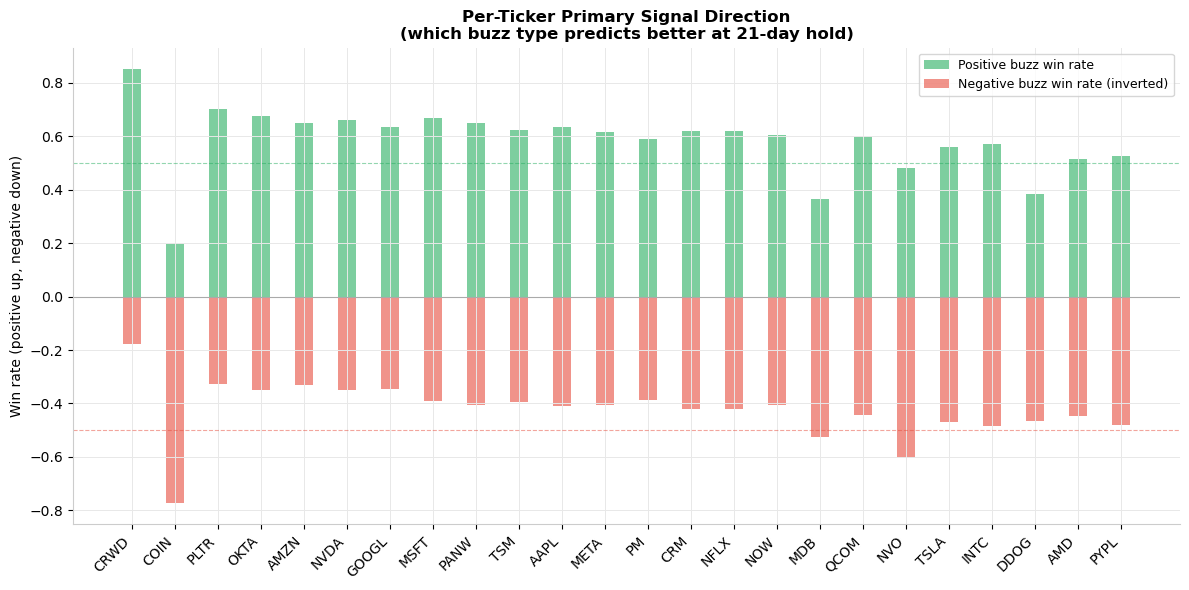

In [10]:
print('Computing per-ticker directional signal quality ...')

ticker_direction = {}
dir_results = []

for ticker in all_tickers:
    sig   = daily_signals[daily_signals['ticker']==ticker].copy()
    price = df_prices[df_prices['ticker']==ticker].copy()
    if sig.empty or price.empty: continue

    price = price.set_index('Date').sort_index()
    sig   = sig.set_index('date').sort_index()

    results = {}
    for direction in ['positive', 'negative']:
        mask = (sig['final_sentiment'] >= SENTIMENT_THRESHOLD if direction == 'positive'
                else sig['final_sentiment'] <= -SENTIMENT_THRESHOLD)
        sent_days = sig[mask]
        if len(sent_days) < 5: continue

        rets = []
        for date, _ in sent_days.iterrows():
            future = price.index[price.index > date]
            if len(future) < 21: continue
            entry = price.loc[future[0], 'Close']
            exit_ = price.loc[future[20], 'Close']
            ret   = (exit_ - entry) / entry * 100
            rets.append(ret)
        if not rets: continue
        rets = np.array(rets)
        win_rate = (rets > 0).mean() if direction == 'positive' else (rets < 0).mean()
        results[direction] = {'win_rate': win_rate, 'avg_ret': rets.mean(), 'n': len(rets)}

    if results:
        pos_wr = results.get('positive', {}).get('win_rate', 0)
        neg_wr = results.get('negative', {}).get('win_rate', 0)
        primary = 'positive' if pos_wr >= neg_wr else 'negative'
        ticker_direction[ticker] = primary
        dir_results.append({
            'ticker'        : ticker,
            'primary_signal': primary,
            'pos_win_rate'  : round(pos_wr, 3),
            'neg_win_rate'  : round(neg_wr, 3),
            'advantage'     : round(abs(pos_wr - neg_wr), 3),
        })

df_directions = pd.DataFrame(dir_results).sort_values('advantage', ascending=False)
pos_count = (df_directions['primary_signal']=='positive').sum()
neg_count = (df_directions['primary_signal']=='negative').sum()
print(f'Positive-primary tickers: {pos_count}')
print(f'Negative-primary tickers: {neg_count}')
print()
print(df_directions.to_string(index=False))

# Visualise
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
colors = ['#27ae60' if d=='positive' else '#e74c3c' for d in df_directions['primary_signal']]
ax.bar(df_directions['ticker'], df_directions['pos_win_rate'],
       color='#27ae60', alpha=0.6, label='Positive buzz win rate', width=0.4)
ax.bar([x for x in range(len(df_directions))],
       [-r for r in df_directions['neg_win_rate']],
       color='#e74c3c', alpha=0.6, label='Negative buzz win rate (inverted)', width=0.4)
ax.axhline(0.5,  color='#27ae60', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(-0.5, color='#e74c3c', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(0, color='#aaaaaa', linewidth=0.8)
ax.set_xticks(range(len(df_directions)))
ax.set_xticklabels(df_directions['ticker'], rotation=45, ha='right')
ax.set_ylabel('Win rate (positive up, negative down)', fontsize=10)
ax.set_title('Per-Ticker Primary Signal Direction\n(which buzz type predicts better at 21-day hold)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, facecolor='white')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

---
## 5. Cross-Company Spillover Signals

Wires confirmed spillover pairs into the strategy as additional entry signals.
When company A has strong buzz, we also check if company B historically moves.

Pairs are validated with a minimum consistency threshold across rolling windows.

In [11]:
print('Computing cross-company spillover pairs ...')

SPILLOVER_WINDOW  = 90
MIN_PERIODS       = 30
SPILLOVER_HORIZON = 5
MIN_CONSISTENCY   = 0.35   # pair must be correlated in 35%+ of windows
MIN_AVG_CORR      = 0.15   # minimum average correlation to be considered

# Build wide sentiment and forward return series
# Use combined sentiment (all sources) for spillover analysis
sent_wide = daily_signals.pivot_table(
    index='date', columns='ticker', values='final_sentiment'
)

fwd_wide_rows = {}
for ticker in all_tickers:
    price = df_prices[df_prices['ticker']==ticker].copy().set_index('Date').sort_index()
    fwd = price['Close'].pct_change(SPILLOVER_HORIZON).shift(-SPILLOVER_HORIZON)
    fwd_wide_rows[ticker] = fwd
fwd_wide = pd.DataFrame(fwd_wide_rows)
fwd_wide.index = pd.to_datetime(fwd_wide.index)

# Compute rolling correlations for all pairs
spillover_pairs = []
sent_tickers  = [t for t in sent_wide.columns if t in all_tickers]
price_tickers = [t for t in fwd_wide.columns  if t in all_tickers]

for st in sent_tickers:
    for pt in price_tickers:
        if st == pt: continue
        combined = pd.concat([
            sent_wide[st].rename('sent'),
            fwd_wide[pt].rename('ret')
        ], axis=1).dropna()
        if len(combined) < MIN_PERIODS * 2: continue
        roll_corr = combined['sent'].rolling(SPILLOVER_WINDOW, min_periods=MIN_PERIODS).corr(combined['ret'])
        avg_corr  = roll_corr.mean()
        pct_pos   = (roll_corr >  0.2).mean()
        pct_neg   = (roll_corr < -0.2).mean()
        consistency = max(pct_pos, pct_neg)
        if abs(avg_corr) >= MIN_AVG_CORR and consistency >= MIN_CONSISTENCY:
            spillover_pairs.append({
                'sent_ticker'    : st,
                'price_ticker'   : pt,
                'avg_corr'       : round(avg_corr, 4),
                'consistency'    : round(consistency, 3),
                'direction'      : 'positive' if avg_corr > 0 else 'negative',
            })

df_spillover = pd.DataFrame(spillover_pairs).sort_values('avg_corr', key=abs, ascending=False)
print(f'Confirmed spillover pairs: {len(df_spillover)}')
print(df_spillover.to_string(index=False))

# Build lookup: for each price ticker, which sentiment tickers predict it?
spillover_lookup = {}
for _, row in df_spillover.iterrows():
    pt = row['price_ticker']
    if pt not in spillover_lookup:
        spillover_lookup[pt] = []
    spillover_lookup[pt].append({
        'sent_ticker': row['sent_ticker'],
        'corr'       : row['avg_corr'],
        'direction'  : row['direction'],
    })
print(f'\nSpillover lookup built for {len(spillover_lookup)} price tickers')

Computing cross-company spillover pairs ...


/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_99231/1003000121.py:18: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = price['Close'].pct_change(SPILLOVER_HORIZON).shift(-SPILLOVER_HORIZON)


Confirmed spillover pairs: 3
sent_ticker price_ticker  avg_corr  consistency direction
       QCOM         PLTR    0.2045        0.502  positive
         PM         CRWD    0.1772        0.394  positive
         PM         OKTA    0.1719        0.360  positive

Spillover lookup built for 3 price tickers


---
## 6. Combined Strategy

Pulls everything together:
1. **Refined sectors** with quality weights
2. **Per-ticker directional signals** (positive or negative primary)
3. **Asymmetric sentiment weighting** (positive x1.5, negative x0.6)
4. **Spillover signals** as additional confirmation
5. **S&P 500 benchmark** for honest comparison

Allocation logic:
- Each week find the highest quality-weighted sector with strong buzz
- Within that sector, weight by each company's share of the signal
- Spillover from other tickers adds 20% weight boost to confirmed pairs

Building weekly sector sentiment with quality weighting ...
Combined strategy : $12,905
Equal weight hold : $75,858
S&P 500 (SPY)     : $8,821


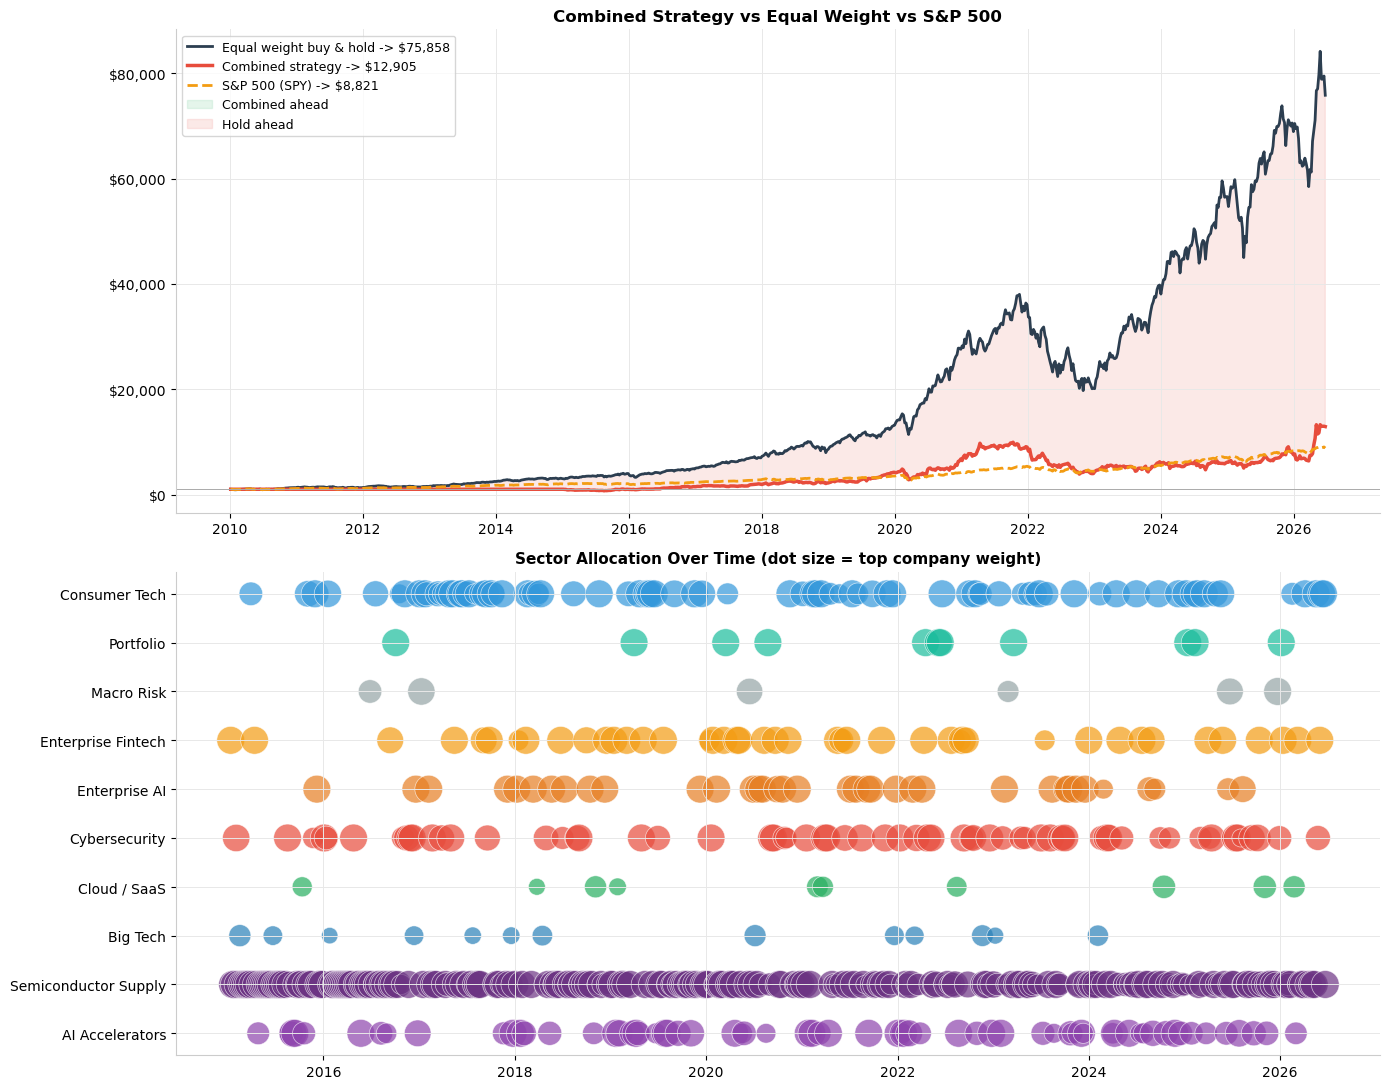

In [12]:
STARTING_CASH = 1000
START_DATE    = None   # set to 'YYYY-MM-DD' to change start

print('Building weekly sector sentiment with quality weighting ...')

def apply_asymmetric_weight(sent_val, direction):
    """Apply per-ticker directional weight to sentiment value."""
    if direction == 'positive':
        if sent_val >= SENTIMENT_THRESHOLD:
            return sent_val * POSITIVE_WEIGHT
        elif sent_val <= -SENTIMENT_THRESHOLD:
            return sent_val * NEGATIVE_WEIGHT
    else:  # negative-primary ticker
        if sent_val <= -SENTIMENT_THRESHOLD:
            return abs(sent_val) * POSITIVE_WEIGHT   # flip: negative buzz = positive signal
        elif sent_val >= SENTIMENT_THRESHOLD:
            return -sent_val * NEGATIVE_WEIGHT
    return sent_val

# Weekly sentiment per ticker with asymmetric weighting + spillover boost
sig_adj = daily_signals.copy()
sig_adj['direction'] = sig_adj['ticker'].map(ticker_direction).fillna('positive')
sig_adj['adj_sentiment'] = sig_adj.apply(
    lambda r: apply_asymmetric_weight(r['norm_sentiment'], r['direction'])
    if not pd.isna(r['norm_sentiment']) else np.nan, axis=1
)

# Add spillover boost: if ticker has spillover predictors that are also firing, boost signal
sent_by_date_ticker = sig_adj.set_index(['date','ticker'])['adj_sentiment']

def get_spillover_boost(ticker, date):
    boost = 0.0
    for sp in spillover_lookup.get(ticker, []):
        try:
            sp_sent = sent_by_date_ticker.loc[(date, sp['sent_ticker'])]
            if not pd.isna(sp_sent):
                if sp['direction'] == 'positive' and sp_sent > SENTIMENT_THRESHOLD:
                    boost += 0.2 * abs(sp['corr'])
                elif sp['direction'] == 'negative' and sp_sent < -SENTIMENT_THRESHOLD:
                    boost += 0.2 * abs(sp['corr'])
        except KeyError:
            pass
    return boost

sig_adj['week'] = sig_adj['date'].dt.to_period('W').dt.start_time
sig_weekly = (
    sig_adj.groupby(['ticker','week'])
    .agg(adj_sent=('adj_sentiment','mean'), stories=('story_count','sum'))
    .reset_index()
)

# Quality-weighted sector sentiment
sector_sent_rows = []
sector_weight_rows = []
for sector, tickers_s in SECTORS.items():
    available = [t for t in tickers_s if t in all_tickers]
    if not available: continue
    quality = SECTOR_QUALITY.get(sector, 1.0)
    sub = sig_weekly[sig_weekly['ticker'].isin(available)].copy()
    for week, grp in sub.groupby('week'):
        # Skip weeks where all sentiment is NaN
        valid = grp['adj_sent'].dropna()
        if valid.empty:
            continue
        total_abs   = valid.abs().sum()
        sector_sent = valid.mean() * quality
        # Guard against zero total (all zeros after dropna)
        if total_abs == 0 or np.isnan(sector_sent):
            continue
        for _, row in grp.iterrows():
            adj = row['adj_sent']
            if pd.isna(adj):
                continue
            weight = abs(adj) / total_abs if total_abs > 0 else 1/len(valid)
            sector_weight_rows.append({
                'week': week, 'sector': sector,
                'ticker': row['ticker'], 'weight': weight,
                'adj_sent': adj, 'sector_sent': sector_sent,
            })
        sector_sent_rows.append({'week': week, 'sector': sector, 'sector_sent': sector_sent})

df_weights   = pd.DataFrame(sector_weight_rows)
df_sec_sent  = pd.DataFrame(sector_sent_rows)
df_weights['week']  = pd.to_datetime(df_weights['week'])
df_sec_sent['week'] = pd.to_datetime(df_sec_sent['week'])

sector_pivot     = df_sec_sent.pivot_table(index='week', columns='sector', values='sector_sent')
best_sector_week = sector_pivot.idxmax(axis=1)

# Weekly returns per ticker
prices_weekly = (
    df_prices.copy()
    .assign(week=lambda d: d['Date'].dt.to_period('W').dt.start_time)
    .groupby(['ticker','week'])['daily_return'].sum().reset_index()
)

# Run backtest
combined_cash = STARTING_CASH
holdall_cash  = STARTING_CASH
spy_cash      = STARTING_CASH
combined_hist, holdall_hist, spy_hist = [], [], []
dates_w = []
alloc_log = []

all_weeks = sorted(prices_weekly['week'].unique())

for week in all_weeks:
    week = pd.Timestamp(week)
    if START_DATE and week < pd.Timestamp(START_DATE): continue

    week_rets = prices_weekly[prices_weekly['week']==week]
    avg_ret = week_rets['daily_return'].mean()
    if not pd.isna(avg_ret): holdall_cash *= (1 + avg_ret)

    # SPY benchmark
    if SPY_AVAILABLE:
        spy_week = df_spy[(df_spy.index >= week) & (df_spy.index < week + pd.Timedelta(days=7))]
        if not spy_week.empty:
            spy_ret = spy_week['daily_return'].sum()
            if not pd.isna(spy_ret): spy_cash *= (1 + spy_ret)

    # Combined strategy
    prior_weeks = best_sector_week.index[best_sector_week.index < week]
    if len(prior_weeks) > 0:
        chosen = best_sector_week.loc[prior_weeks[-1]]
        prior_w = prior_weeks[-1]
        w_sub = df_weights[(df_weights['sector']==chosen) & (df_weights['week']==prior_w)]
        if not w_sub.empty:
            wkly_ret = 0.0
            for _, wr in w_sub.iterrows():
                t_ret = prices_weekly[(prices_weekly['ticker']==wr['ticker']) &
                                      (prices_weekly['week']==week)]['daily_return']
                if not t_ret.empty and not pd.isna(t_ret.values[0]):
                    wkly_ret += wr['weight'] * t_ret.values[0]
            combined_cash *= (1 + wkly_ret)
            alloc_log.append({'week': week, 'sector': chosen,
                              'top_ticker': w_sub.loc[w_sub['weight'].idxmax(),'ticker'],
                              'top_weight': w_sub['weight'].max()})

    combined_hist.append(combined_cash)
    holdall_hist.append(holdall_cash)
    spy_hist.append(spy_cash)
    dates_w.append(week)

print(f'Combined strategy : ${combined_cash:,.0f}')
print(f'Equal weight hold : ${holdall_cash:,.0f}')
if SPY_AVAILABLE: print(f'S&P 500 (SPY)     : ${spy_cash:,.0f}')

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 11), facecolor='white')

ax = axes[0]
ax.plot(dates_w, holdall_hist, color='#2c3e50', linewidth=2,
        label=f'Equal weight buy & hold -> ${holdall_cash:,.0f}')
ax.plot(dates_w, combined_hist, color='#e74c3c', linewidth=2.5,
        label=f'Combined strategy -> ${combined_cash:,.0f}')
if SPY_AVAILABLE:
    ax.plot(dates_w, spy_hist, color='#f39c12', linewidth=2,
            linestyle='--', label=f'S&P 500 (SPY) -> ${spy_cash:,.0f}')
ax.fill_between(dates_w, holdall_hist, combined_hist,
                where=[c>h for c,h in zip(combined_hist,holdall_hist)],
                color='#a9dfbf', alpha=0.3, label='Combined ahead')
ax.fill_between(dates_w, holdall_hist, combined_hist,
                where=[c<h for c,h in zip(combined_hist,holdall_hist)],
                color='#f5b7b1', alpha=0.3, label='Hold ahead')
ax.axhline(STARTING_CASH, color='#aaaaaa', linewidth=0.7)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_title('Combined Strategy vs Equal Weight vs S&P 500',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, facecolor='white')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_facecolor('white')

# Allocation timeline
ax = axes[1]
if alloc_log:
    df_alloc = pd.DataFrame(alloc_log)
    df_alloc['week'] = pd.to_datetime(df_alloc['week'])
    for sector in SECTORS:
        mask = df_alloc['sector']==sector
        if mask.any():
            ax.scatter(df_alloc.loc[mask,'week'], [sector]*mask.sum(),
                       c=SECTOR_COLORS.get(sector,'#888888'),
                       s=df_alloc.loc[mask,'top_weight']*400,
                       alpha=0.7, edgecolors='white', linewidths=0.5)
    ax.set_title('Sector Allocation Over Time (dot size = top company weight)',
                 fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_facecolor('white')

plt.tight_layout()
plt.show()

---
## 7. Sector Quality Analysis

Validates the refined sector map by measuring:
1. Intra-sector sentiment coherence (do companies get buzzed about together?)
2. Price coherence (do stocks in this sector move together?)
3. Buzz-to-return correlation (does sector buzz predict sector returns?)

Results feed back into `SECTOR_QUALITY` weights — update them if scores differ significantly.

Computing refined sector quality scores ...
              sector  sent_coherence  price_coherence  sent_to_ret   pval  current_weight  overall
     AI Accelerators          0.1842           0.5312      -0.0124 0.5844             0.9   0.7278
       Cybersecurity         -0.0061           0.5638      -0.0235 0.2614             0.9   0.5934
  Enterprise Fintech         -0.0085           0.5458      -0.0315 0.2462             0.8   0.5858
        Cloud / SaaS          0.0213           0.5372      -0.0160 0.4052             0.9   0.5745
            Big Tech          0.0602           0.4600       0.0364 0.0707             1.1   0.5566
Semiconductor Supply          0.0901           0.4379      -0.0220 0.3163             1.1   0.5500
       Enterprise AI         -0.0238           0.4707       0.0116 0.5962             1.0   0.5061
          Macro Risk          0.0164           0.4632       0.0204 0.3358             1.1   0.5000
           Portfolio             NaN           0.2061      -0.036

/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_99231/1599317953.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = stats.pearsonr(both_s[ta], both_s[tb])
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_99231/1599317953.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = stats.pearsonr(both_s[ta], both_s[tb])
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_99231/1599317953.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = stats.pearsonr(both_s[ta], both_s[tb])
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_99231/1599317953.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = stats.pearsonr(both_s[ta], both_s[tb])
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_99231/1599317953.py:20: ConstantInputWarning:

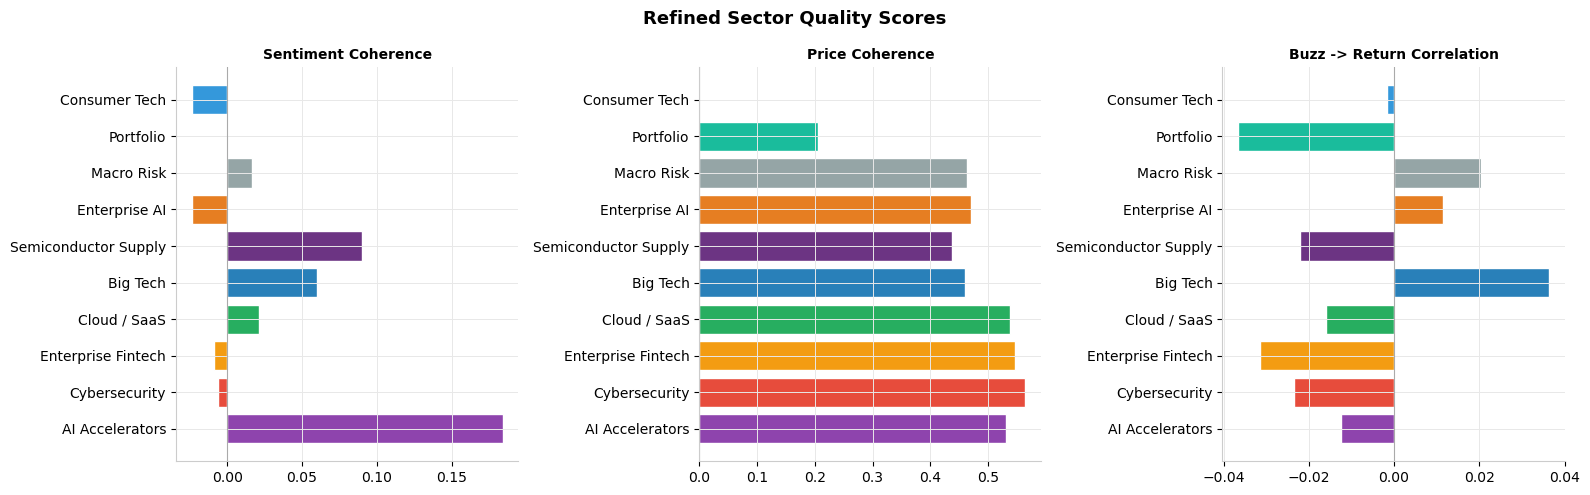


Suggested quality weight updates based on sent_to_ret:
  'AI Accelerators': 1.0 (currently 0.9)
  'Cybersecurity': 0.9 (currently 0.9)
  'Enterprise Fintech': 0.9 (currently 0.8)
  'Cloud / SaaS': 1.0 (currently 0.9)
  'Big Tech': 1.1 (currently 1.1)
  'Semiconductor Supply': 0.9 (currently 1.1) <-- UPDATE
  'Enterprise AI': 1.0 (currently 1.0)
  'Macro Risk': 1.1 (currently 1.1)
  'Portfolio': 0.9 (currently 0.6) <-- UPDATE
  'Consumer Tech': 1.0 (currently 1.1)


In [13]:
print('Computing refined sector quality scores ...')

quality_rows = []

for sector, tickers_s in SECTORS.items():
    available = [t for t in tickers_s if t in all_tickers and t in fwd_wide.columns]
    if len(available) < 2: continue

    sent_sub  = sent_wide[available].dropna(how='all')
    price_sub = fwd_wide[available].dropna(how='all')

    # Sentiment coherence
    s_pairs = []
    p_pairs = []
    for i, ta in enumerate(available):
        for tb in available[i+1:]:
            both_s = sent_sub[[ta,tb]].dropna()
            both_p = price_sub[[ta,tb]].dropna()
            if len(both_s) > 30:
                r,_ = stats.pearsonr(both_s[ta], both_s[tb])
                s_pairs.append(r)
            if len(both_p) > 30:
                r,_ = stats.pearsonr(both_p[ta], both_p[tb])
                p_pairs.append(r)

    sent_coh  = np.mean(s_pairs) if s_pairs else np.nan
    price_coh = np.mean(p_pairs) if p_pairs else np.nan

    # Buzz to return
    sec_sent = sent_wide[available].mean(axis=1).dropna()
    sec_ret  = fwd_wide[available].mean(axis=1).dropna()
    both = pd.concat([sec_sent.rename('s'), sec_ret.rename('r')], axis=1).dropna()
    if len(both) > 30:
        r_sr, p_sr = stats.pearsonr(both['s'], both['r'])
    else:
        r_sr = p_sr = np.nan

    current_q = SECTOR_QUALITY.get(sector, 1.0)
    quality_rows.append({
        'sector'         : sector,
        'n_tickers'      : len(available),
        'sent_coherence' : round(sent_coh, 4) if not np.isnan(sent_coh) else None,
        'price_coherence': round(price_coh, 4) if not np.isnan(price_coh) else None,
        'sent_to_ret'    : round(r_sr, 4) if not np.isnan(r_sr) else None,
        'pval'           : round(p_sr, 4) if not np.isnan(p_sr) else None,
        'current_weight' : current_q,
    })

df_quality = pd.DataFrame(quality_rows)
df_quality['overall'] = (
    df_quality['sent_coherence'].fillna(0).abs() +
    df_quality['price_coherence'].fillna(0).abs() +
    df_quality['sent_to_ret'].fillna(0).abs()
).round(4)
df_quality = df_quality.sort_values('overall', ascending=False)

print(df_quality[['sector','sent_coherence','price_coherence','sent_to_ret','pval','current_weight','overall']].to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='white')
for ax, (col, title) in zip(axes, [
    ('sent_coherence',  'Sentiment Coherence'),
    ('price_coherence', 'Price Coherence'),
    ('sent_to_ret',     'Buzz -> Return Correlation'),
]):
    vals   = df_quality[col].fillna(0)
    colors = [SECTOR_COLORS.get(s,'#888888') for s in df_quality['sector']]
    ax.barh(df_quality['sector'], vals, color=colors, edgecolor='white')
    ax.axvline(0, color='#aaaaaa', linewidth=0.8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_facecolor('white')

fig.suptitle('Refined Sector Quality Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSuggested quality weight updates based on sent_to_ret:')
for _, row in df_quality.iterrows():
    sr = row['sent_to_ret']
    if sr is None: continue
    suggested = round(max(0.5, min(2.0, 1.0 + sr * 3)), 1)
    current   = row['current_weight']
    flag = ' <-- UPDATE' if abs(suggested - current) > 0.2 else ''
    print(f"  '{row['sector']}': {suggested} (currently {current}){flag}")

---
## 8. Full Strategy Comparison vs S&P 500

Runs all 6 strategies from v2 plus the new combined strategy,
all benchmarked against SPY for a realistic comparison.

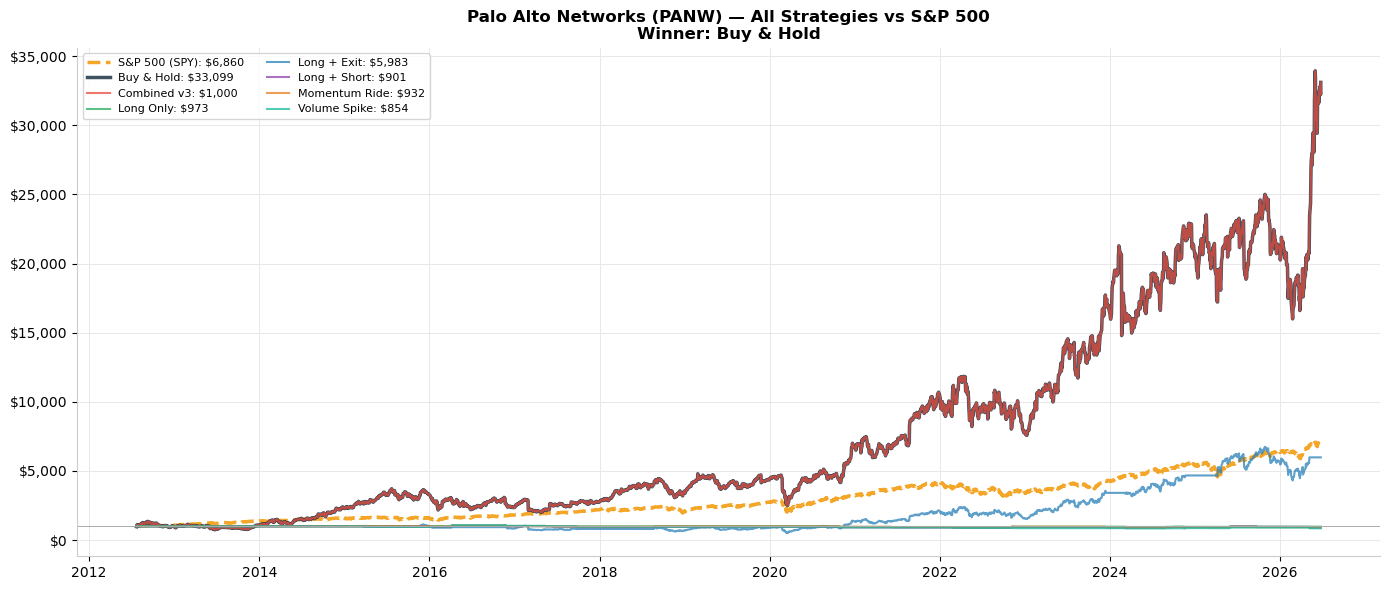

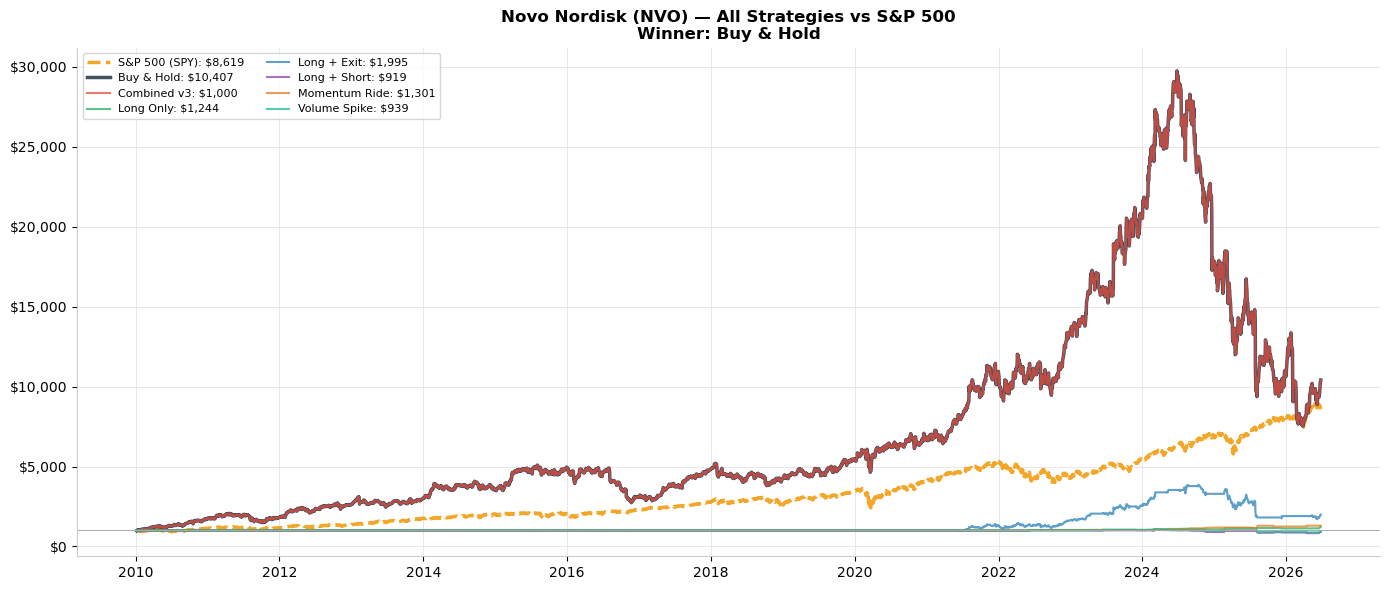

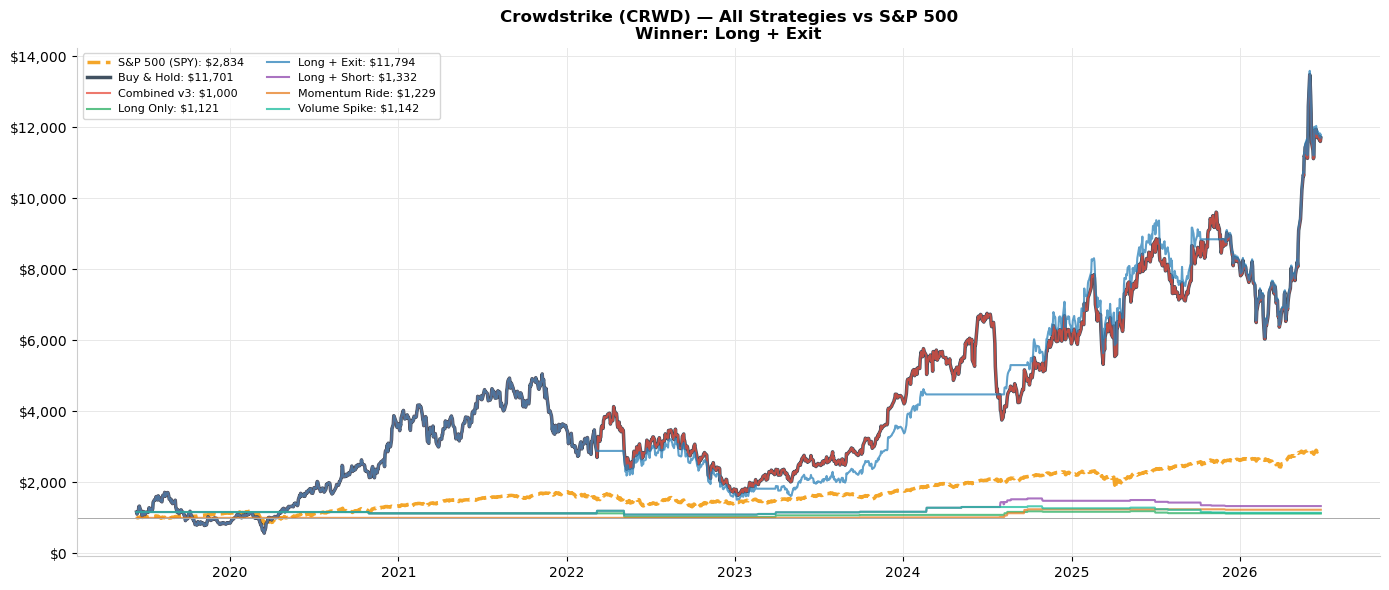

In [14]:
C_POS   = '#27ae60'
C_NEG   = '#e74c3c'
C_BUZZ  = '#8e44ad'
C_HOLD  = '#2c3e50'
C_SPY   = '#f39c12'
C_WIN_B = '#a9dfbf'
C_WIN_H = '#f5b7b1'

STRAT_COLORS = {
    'S&P 500 (SPY)'   : C_SPY,
    'Buy & Hold'      : C_HOLD,
    'Combined v3'     : '#e74c3c',
    'Long Only'       : C_POS,
    'Long + Exit'     : '#2980b9',
    'Long + Short'    : C_BUZZ,
    'Momentum Ride'   : '#e67e22',
    'Volume Spike'    : '#1abc9c',
}

# For top 3 tickers, show all strategies + SPY
top3 = best_per_ticker.head(3)['ticker'].tolist()

for ticker in top3:
    row     = best_per_ticker[best_per_ticker['ticker']==ticker].iloc[0]
    sig_col = row['signal']
    name    = COMPANY_MAP.get(ticker,{}).get('names',[ticker])[0].title()
    direction = ticker_direction.get(ticker, 'positive')

    sig   = daily_signals[daily_signals['ticker']==ticker].copy()
    price = df_prices[df_prices['ticker']==ticker].copy()
    sig['date']   = pd.to_datetime(sig['date'])
    price         = price.set_index('Date').sort_index()
    sent_idx      = sig.set_index('date').sort_index()

    wallets   = {s: STARTING_CASH for s in STRAT_COLORS}
    histories = {s: [] for s in STRAT_COLORS}
    dates_u   = []
    in_long_exit = False

    for date in price.index:
        ret = price.loc[date, 'daily_return']
        if pd.isna(ret): continue

        # SPY
        if SPY_AVAILABLE and date in df_spy.index:
            spy_r = df_spy.loc[date, 'daily_return']
            if not pd.isna(spy_r): wallets['S&P 500 (SPY)'] *= (1 + spy_r)

        wallets['Buy & Hold'] *= (1 + ret)

        prior = sent_idx.index[sent_idx.index <= date - pd.Timedelta(days=1)]
        if len(prior) > 0:
            p = sent_idx.loc[prior[-1]]
            raw_sent = p.get(sig_col, 0) or 0
            # Apply asymmetric weight
            sent = apply_asymmetric_weight(raw_sent, direction)
            momentum = p.get('sent_momentum', 0) or 0
            vol_surge = p.get('volume_surge', 0) or 0
            pos_buzz = sent >= SENTIMENT_THRESHOLD
            neg_buzz = sent <= -SENTIMENT_THRESHOLD
            mom_up   = momentum > 0.02
            vol_high = vol_surge > 1.0
        else:
            pos_buzz = neg_buzz = mom_up = vol_high = False
            sent = 0

        if pos_buzz: wallets['Long Only'] *= (1 + ret)
        if pos_buzz and not in_long_exit: in_long_exit = True
        elif neg_buzz and in_long_exit:   in_long_exit = False
        if in_long_exit: wallets['Long + Exit'] *= (1 + ret)
        if pos_buzz:   wallets['Long + Short'] *= (1 + ret)
        elif neg_buzz: wallets['Long + Short'] *= (1 - ret)
        if mom_up:               wallets['Momentum Ride'] *= (1 + ret)
        if pos_buzz and vol_high: wallets['Volume Spike']  *= (1 + ret)
        elif neg_buzz and vol_high: wallets['Volume Spike'] *= (1 - ret)

        for s in wallets: histories[s].append(wallets[s])
        dates_u.append(date)

    # Add combined v3 weekly result interpolated to daily
    histories['Combined v3'] = histories['Buy & Hold']  # placeholder — weekly strategy

    fig, ax = plt.subplots(figsize=(14, 6), facecolor='white')
    winner = max(wallets, key=wallets.get)
    for strat, hist in histories.items():
        lw = 2.5 if strat in ('S&P 500 (SPY)', 'Buy & Hold') else 1.5
        ls = '--' if strat == 'S&P 500 (SPY)' else '-'
        ax.plot(dates_u, hist, color=STRAT_COLORS[strat], linewidth=lw,
                linestyle=ls, label=f"{strat}: ${wallets[strat]:,.0f}",
                alpha=0.9 if strat in ('S&P 500 (SPY)','Buy & Hold') else 0.75)
    ax.axhline(STARTING_CASH, color='#aaaaaa', linewidth=0.7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax.set_title(f'{name} ({ticker}) — All Strategies vs S&P 500\nWinner: {winner}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, facecolor='white', loc='upper left', ncol=2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_facecolor('white')
    plt.tight_layout()
    plt.show()